In [ ]:
#PREQUESITES:

# beesup_llm-framework: https://gitlab.tu-ilmenau.de/mase4201/beesup-llm-framework.git
# follow the instructions in the README.md to install the framework
# use beesup_environment.yaml to create a conda environment and run this notebook in it

In [20]:
import os
import sys
import copy
import pandas as pd

import beesup_llm
from beesup_llm.llm import *
from beesup_llm.emb import *
from beesup_llm.rag import *

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

#better display of dataframes
from IPython.display import display, HTML
css = """
<style type='text/css'>
.dataframe th, .dataframe td {
    white-space: nowrap;
    text-align: left;
    padding: 4px;
    line-height: 1; /* This sets the line height to one */
}
</style>
"""
display(HTML(css))

In [ ]:
import importlib #only needed for Development
# development utils
prefixpaths=['beesup_llm']

def get_modules_with_prefixpath(prefixpaths):
    if isinstance(prefixpaths, str):
        prefixpaths = [prefixpaths]

    modules=dict()
    all_modules = sys.modules.copy()
    for prefixpath in prefixpaths:
        for module_path, module in all_modules.items():
            if module_path.startswith(prefixpath):
                modules[module_path] = module

    return modules

def reimport(prefixpaths=prefixpaths):
    for module_path, module in get_modules_with_prefixpath(prefixpaths).items():
        importlib.reload(sys.modules[module_path])
        globals().update({name: getattr(module, name) for name in dir(module) if not name.startswith('_')})

LOGGING_FORMAT='%(asctime)s - %(filename)s - %(name)s - %(funcName)s - %(levelname)s - %(message)s'

import logging
logging.basicConfig(
    level=logging.INFO,
    format=LOGGING_FORMAT)

def set_info(prefixpaths=prefixpaths):
    for module_path in get_modules_with_prefixpath(prefixpaths).keys():
        logger = logging.getLogger(module_path)
        logger.setLevel(logging.INFO)
        logging.getLogger().setLevel(logging.INFO)

def set_debug(prefixpaths=prefixpaths):
    for module_path in get_modules_with_prefixpath(prefixpaths).keys():
        logger = logging.getLogger(module_path)
        logger.setLevel(logging.DEBUG)
        logging.getLogger().setLevel(logging.DEBUG)

set_info() 

# Loading Embedding- & and LLM Pipeline

In [3]:
# Loading Embedding Pipeline
emb_pipe=QwenPipeline()
emb_pipe.load_model()
emb_model=copy.deepcopy(emb_pipe.model)

2025-03-19 12:08:12,673 - emb.py - beesup_llm.emb - load_model - INFO - Loading model Alibaba-NLP/gte-Qwen2-7B-instruct
2025-03-19 12:08:36,734 - modeling.py - accelerate.utils.modeling - get_balanced_memory - INFO - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

In [4]:
# Loading LLM Pipeline
llm_pipe=LlamaPipeline()
llm_pipe.prepare_inference()
llm_model=copy.deepcopy(llm_pipe.model)

2025-03-19 12:10:09,372 - llm.py - beesup_llm.llm - load_model - INFO - Loading model meta-llama/Meta-Llama-3.1-8B-Instruct
2025-03-19 12:10:09,959 - modeling.py - accelerate.utils.modeling - get_balanced_memory - INFO - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

# Prepare Knowledge-Chunks

In [5]:
# Load chunks from Wikipedia
from langchain_community.document_loaders import WikipediaLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter

docs = WikipediaLoader(query='Technische Universität Ilmenau', lang='de', load_max_docs=4).load()
splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50)
chunks = splitter.split_documents(docs)

chunks_df=pd.DataFrame(
    dict(
        page_content = [c.page_content for c in chunks],
        summary = [c.metadata['summary'] for c in chunks],
        title = [c.metadata['title'] for c in chunks],
        source = [c.metadata['source'] for c in chunks]))


CHUNK_TEMPLATE="TITLE: {title}\n\nSUMMARY: {summary}\n\nCONTENT: {page_content}"

chunks_df['chunk']=chunks_df.apply(lambda x: CHUNK_TEMPLATE.format(**x), axis=1)
chunks_df['n_chars']=chunks_df['chunk'].apply(len)
chunks_df.head(4)

,page_content,summary,title,source,chunk,n_chars
0,Die Technische Universität Ilmenau ist eine Un...,Die Technische Universität Ilmenau ist eine Un...,Technische Universität Ilmenau,https://de.wikipedia.org/wiki/Technische_Unive...,TITLE: Technische Universität Ilmenau\n\nSUMMA...,847
1,Forschung und Lehre sind stark ingenieurwissen...,Die Technische Universität Ilmenau ist eine Un...,Technische Universität Ilmenau,https://de.wikipedia.org/wiki/Technische_Unive...,TITLE: Technische Universität Ilmenau\n\nSUMMA...,802
2,== Fakultäten ==\nElektrotechnik und Informati...,Die Technische Universität Ilmenau ist eine Un...,Technische Universität Ilmenau,https://de.wikipedia.org/wiki/Technische_Unive...,TITLE: Technische Universität Ilmenau\n\nSUMMA...,769
3,== Schwerpunkte in der Forschung ==\n\nDie tra...,Die Technische Universität Ilmenau ist eine Un...,Technische Universität Ilmenau,https://de.wikipedia.org/wiki/Technische_Unive...,TITLE: Technische Universität Ilmenau\n\nSUMMA...,755


In [ ]:
# add embedding column to chunks_df (inplace)
emb_pipe.add_emb(
    chunks_df,
    txt_key='chunk',
    emb_key='emb',
    batch_size=8, #if model crashes, reduce batch_size
    instruction=None,
    verbose=True
    )

chunks_df

,page_content,summary,title,source,chunk,n_chars,emb
0,Die Technische Universität Ilmenau ist eine Un...,Die Technische Universität Ilmenau ist eine Un...,Technische Universität Ilmenau,https://de.wikipedia.org/wiki/Technische_Unive...,TITLE: Technische Universität Ilmenau\n\nSUMMA...,847,"[0.005833, -0.004772, -0.002697, 0.010086, 0.0..."
1,Forschung und Lehre sind stark ingenieurwissen...,Die Technische Universität Ilmenau ist eine Un...,Technische Universität Ilmenau,https://de.wikipedia.org/wiki/Technische_Unive...,TITLE: Technische Universität Ilmenau\n\nSUMMA...,802,"[-0.00378, 0.00488, -0.02007, 0.00505, 0.01843..."
2,== Fakultäten ==\nElektrotechnik und Informati...,Die Technische Universität Ilmenau ist eine Un...,Technische Universität Ilmenau,https://de.wikipedia.org/wiki/Technische_Unive...,TITLE: Technische Universität Ilmenau\n\nSUMMA...,769,"[0.005215, 0.007366, -0.0004776, 0.00905, 0.02..."
3,== Schwerpunkte in der Forschung ==\n\nDie tra...,Die Technische Universität Ilmenau ist eine Un...,Technische Universität Ilmenau,https://de.wikipedia.org/wiki/Technische_Unive...,TITLE: Technische Universität Ilmenau\n\nSUMMA...,755,"[0.0, 0.004726, -0.001716, 0.0093, 0.008354, 0..."
4,Funktionale Materialien und Technologien\nInte...,Die Technische Universität Ilmenau ist eine Un...,Technische Universität Ilmenau,https://de.wikipedia.org/wiki/Technische_Unive...,TITLE: Technische Universität Ilmenau\n\nSUMMA...,697,"[-0.001811, -0.0007696, -0.01483, 0.002636, 0...."
...,...,...,...,...,...,...,...
76,bereits in der Zeitschrift Cicero veröffentlic...,André D. Thess (* 22. Februar 1964 in Leningra...,André Thess,https://de.wikipedia.org/wiki/Andr%C3%A9_Thess,TITLE: André Thess\n\nSUMMARY: André D. Thess ...,172,"[-0.02968, 0.02454, 0.002731, -0.01388, 0.0084..."
77,Thess ist Mitglied der FDP im Landesverband Ba...,André D. Thess (* 22. Februar 1964 in Leningra...,André Thess,https://de.wikipedia.org/wiki/Andr%C3%A9_Thess,TITLE: André Thess\n\nSUMMARY: André D. Thess ...,218,"[-0.02187, 0.02753, 0.003418, -0.008934, -0.00..."
78,== Kontroversen ==\nDie im Juli 2022 von Thess...,André D. Thess (* 22. Februar 1964 in Leningra...,André Thess,https://de.wikipedia.org/wiki/Andr%C3%A9_Thess,TITLE: André Thess\n\nSUMMARY: André D. Thess ...,406,"[-0.0436, 0.01797, 0.01009, -0.01023, -0.01081..."
79,"== Veröffentlichungen ==\n2007, Neuauflage 201...",André D. Thess (* 22. Februar 1964 in Leningra...,André Thess,https://de.wikipedia.org/wiki/Andr%C3%A9_Thess,TITLE: André Thess\n\nSUMMARY: André D. Thess ...,342,"[-0.01352, 0.02438, 0.01282, -0.01799, -0.0083..."


# RAG-Pipeline

In [ ]:
rag_pipe=RAGPipeline(
    chunks_df=chunks_df,
    llm_pipe=llm_pipe,
    emb_pipe=emb_pipe,
    limiters=[
        NumLimiter(100),# prelimit to 100 passages maximum
        TokenLimiter(1000), #briefing is limited to 1000 tokens in maximum
        KneeLimiter()
        ],
    chunk_txt_key='page_content', #not using the chunk column because it contains the title and (long) summary, we are only interested in the content
    query_instruction="Instruct: Given a query, retrieve relevant passages that answer the query\nQuery: "
    )

In [32]:
query_txt="Seit wann gibt es die TU Ilmenau?"

response=rag_pipe(query_txt, stream=True)

Die Geschichte der Universität begann 1894 mit der Einrichtung des Thüringischen Technikums Ilmenau.

<module 'matplotlib.pyplot' from '/home/fboehning/.conda/envs/beesup/lib/python3.12/site-packages/matplotlib/pyplot.py'>

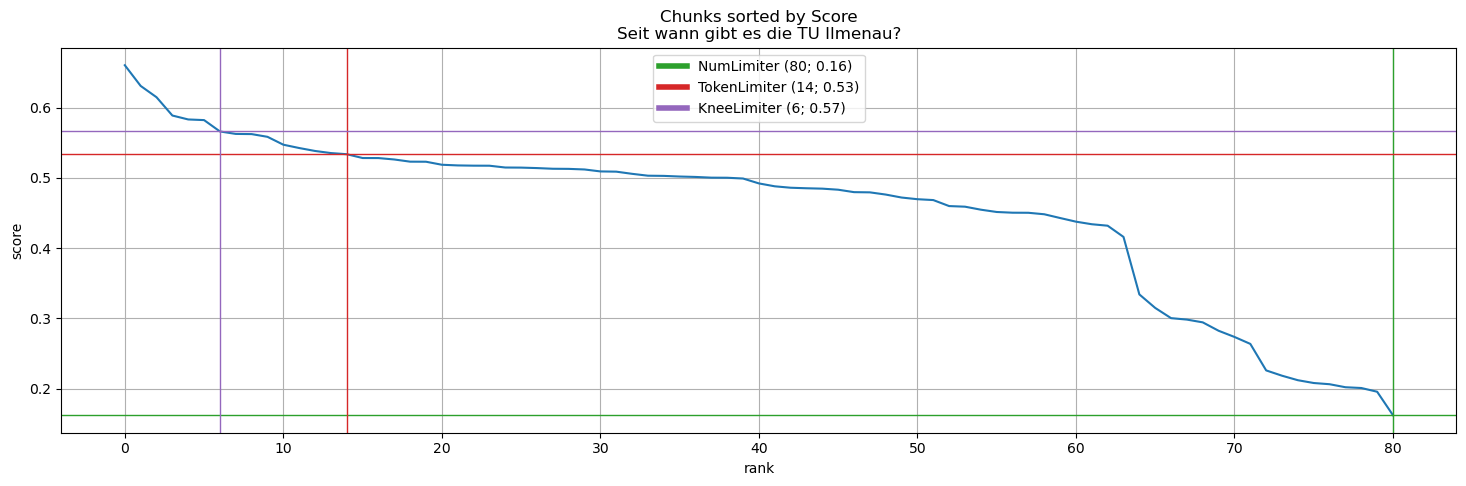

In [33]:
# plot the ranking of recent query: Chunks sorted by score, visualize limiters
rag_pipe._plot

In [19]:
# plot the ranking chunks of recent query
rag_pipe._ranking_df

,chunk,emb,n_tokens,score,NumLimiter,n_tokens_cumsum,TokenLimiter,KneeLimiter
11,TITLE: Technische Universität Ilmenau\n\nSUMMA...,"[-0.005894, 0.003855, -0.02185, 0.00823, 0.020...",176,0.562062,True,176,True,True
1,TITLE: Technische Universität Ilmenau\n\nSUMMA...,"[-0.00378, 0.00488, -0.02007, 0.00505, 0.01843...",207,0.541581,True,383,True,True
6,TITLE: Technische Universität Ilmenau\n\nSUMMA...,"[-0.00554, 0.001813, -0.01607, 0.001529, 0.020...",232,0.535913,True,615,True,True
9,TITLE: Technische Universität Ilmenau\n\nSUMMA...,"[-0.01188, 0.002684, -0.0208, 0.00557, 0.01381...",178,0.534111,True,793,True,True
20,TITLE: Technische Universität Ilmenau\n\nSUMMA...,"[-0.01272, -0.003975, -0.01671, 0.000754, 0.02...",176,0.525704,True,969,True,True
...,...,...,...,...,...,...,...,...
72,TITLE: André Thess\n\nSUMMARY: André D. Thess ...,"[-0.02785, 0.01608, 0.003399, -0.012474, -0.01...",116,0.164593,True,17807,False,False
79,TITLE: André Thess\n\nSUMMARY: André D. Thess ...,"[-0.01352, 0.02438, 0.01282, -0.01799, -0.0083...",118,0.160630,True,17925,False,False
77,TITLE: André Thess\n\nSUMMARY: André D. Thess ...,"[-0.02187, 0.02753, 0.003418, -0.008934, -0.00...",72,0.149062,True,17997,False,False
78,TITLE: André Thess\n\nSUMMARY: André D. Thess ...,"[-0.0436, 0.01797, 0.01009, -0.01023, -0.01081...",123,0.147669,True,18120,False,False


In [23]:
# display the chunks used to brief the LLM
rag_pipe._briefing_df

,chunk,emb,n_tokens,score,NumLimiter,n_tokens_cumsum,TokenLimiter,KneeLimiter
11,TITLE: Technische Universität Ilmenau\n\nSUMMA...,"[-0.005894, 0.003855, -0.02185, 0.00823, 0.020...",176,0.562062,True,176,True,True
1,TITLE: Technische Universität Ilmenau\n\nSUMMA...,"[-0.00378, 0.00488, -0.02007, 0.00505, 0.01843...",207,0.541581,True,383,True,True
6,TITLE: Technische Universität Ilmenau\n\nSUMMA...,"[-0.00554, 0.001813, -0.01607, 0.001529, 0.020...",232,0.535913,True,615,True,True
9,TITLE: Technische Universität Ilmenau\n\nSUMMA...,"[-0.01188, 0.002684, -0.0208, 0.00557, 0.01381...",178,0.534111,True,793,True,True
20,TITLE: Technische Universität Ilmenau\n\nSUMMA...,"[-0.01272, -0.003975, -0.01671, 0.000754, 0.02...",176,0.525704,True,969,True,True


In [ ]:
# print the last prompt message which was used to generate the answer
print(rag_pipe._prompt_messages[-1]['content'])

### CONTEXT:

und eine Außenstelle des Fraunhofer-Instituts für Integrierte Schaltungen (IIS) verstärkt.

Forschung und Lehre sind stark ingenieurwissenschaftlich geprägt und zeichnen sich durch eine enge Verknüpfung der Ingenieurwissenschaften mit den Wirtschaftswissenschaften und Medien, mit der Mathematik sowie mit den Naturwissenschaften aus.

Im Jahr 2004 wurde die Universität in die Deutsche Forschungsgemeinschaft aufgenommen. Im interdisziplinären DFG-Sonderforschungsbereich (SFB) „Neuroelektronik: Biologisch inspirierte Informationsverarbeitung“, an dem die TU Ilmenau mit drei Teilprojekten und drei Doktorandenstellen beteiligt ist,

und Qualifizierungsprogramm spezialisierte Spitzenforschung zu betreiben und auf höchstem Niveau zu promovieren.

Nach dem Zweiten Weltkrieg wurde diese 1947 verstaatlicht und 1950 in eine Fachschule für Elektrotechnik

der Stadt das erste eigene Lehrgebäude, das Alte Technikum (der heutige Curiebau), das durch Anbauten in den Jahren 1896, 1898 und